# Projet Python – Simulation Monte Carlo (GBM) en finance de marché
### Killian Pan

## Introduction

Ce projet d’informatique appliquée à la finance a pour objectif de mettre en œuvre en Python une simulation Monte Carlo afin de modéliser l’évolution future d’un actif financier (action ou indice) à partir de ses données historiques de marché. L’approche retenue repose sur l’hypothèse classique de la finance quantitative selon laquelle le prix du sous-jacent suit un mouvement brownien géométrique (Geometric Brownian Motion – GBM), modèle largement utilisé pour la valorisation et l’analyse de scénarios en gestion des risques.

Dans ce cadre, nous utilisons des données historiques (récupérées via la librairie yfinance / Yahoo Finance) afin de :

- télécharger et visualiser l’évolution du prix d’un actif sur une période choisie

- calculer les log-returns (rendements logarithmiques) et analyser leur dynamique

- estimer les paramètres du modèle (rendements moyens μ et volatilité σ) à partir des rendements

- générer des trajectoires de prix simulées via Monte Carlo, en cohérence avec la fréquence des données (journalière)

- superposer l’historique observé et les scénarios simulés pour comparer visuellement les comportements possibles du marché

Importation des librairies

In [21]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Télécharger les données historiques via yfinance.
Retourner un DataFrame indexé par date avec au moins la colonne 'Close'.

In [22]:
def download_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:

    # Téléchargement des données historiques
    df = yf.download(ticker, start=start_date, end=end_date)

    # Gestion des erreurs
    if df.empty:
        raise ValueError(f"Aucune donnée récupérée pour {ticker}. Vérifie le ticker et les dates.")
    if 'Close' not in df.columns:
        raise ValueError("La colonne 'Close' est introuvable (données Yahoo anormales).")
    
    return df

Afficher graphiquement l'évolution du prix.

In [23]:
def plot_price(df: pd.DataFrame, ticker: str) -> None:

    plt.figure(figsize=(11,5))

    plt.plot(df.index, df['Close'])
    plt.title(f"{ticker} Price")
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid(True, alpha=0.3)

    plt.show()

Calculer les log-returns à partir de 'Close'.
r_t = ln(P_t / P_{t-1})

In [24]:
def compute_log_returns(df: pd.DataFrame) -> pd.Series:

    prices = df['Close'].astype(float)
    log_returns = np.log(1 + prices.pct_change()).dropna()

    return log_returns

Afficher graphiquement les log-returns

In [25]:
def plot_log_returns(log_returns: pd.Series, ticker) -> None:

    plt.figure(figsize=(11,5))

    plt.plot(log_returns.index, log_returns)
    plt.title(f"{ticker} Log Returns")
    plt.xlabel('Date')
    plt.ylabel('Price')

    plt.show()

Estimation journalière de mu et sigma à partir des log-returns historiques.
- mu : moyenne journalière des log-returns
- sigma : écart-type journalier des log-returns

In [26]:
def estimate_mu_sigma(log_returns: pd.Series) -> tuple[float, float]:
    
    mu = float(log_returns.mean())
    sigma = float(log_returns.std())

    return mu, sigma

Simuler des trajectoires GBM (Geometric Brownian Motion) :
S_{t+1} = S_t * exp((mu - 0.5*sigma^2)*dt + sigma *sqrt(dt)*Z)

- mu, sigma : paramètres *journaliers*
- dt : taille d'un pas de simulation exprimé dans l'unité de mu et sigma (dt=1 si mu et sigma journaliers)
- n_steps : nombre de pas (jours) à simuler

Retour : array shape (n_steps+1, n_paths) avec S0 inclus.

In [ ]:
def simulate_mc_paths(
    S0: float, 
    dt: float, 
    mu: float, 
    sigma: float, 
    n_steps: int, 
    n_paths: int, 
    n_seed: int
) -> pd.DataFrame:
    
    # Gestion des erreurs
    if n_steps <= 0 or n_paths <= 0:
        raise ValueError("n_steps et n_paths doivent être > 0.")
    if S0 <= 0:
        raise ValueError("s0 doit être > 0.")
    if sigma < 0:
        raise ValueError("sigma doit être >= 0.")
    
    # Simulation MC
    np.random.seed(n_seed)
    Z = np.random.normal(0, 1, size=(n_steps,n_paths))

    parameters = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    paths = np.zeros((n_steps + 1, n_paths), dtype=float)
    paths[0, :] = S0
    paths[1:, :] = S0 * np.exp(np.cumsum(parameters, axis=0))

    time_index = np.arange(0, n_steps + 1)                       # 0, 1, ..., n_steps
    col_names = [f"path_{i+1}" for i in range(n_paths)]

    df_paths = pd.DataFrame(paths, index=time_index,columns=col_names)

    return df_paths

Afficher graphiquement l'historique (dates réelles) + les trajectoires MC (dates futures).
Aligne parfaitement :
- mc_paths a n_steps+1 points (inclut S0)
- mc_dates a n_steps+1 dates (inclut la dernière date historique)

On veut exactement len(mc_paths) dates :
- 1ère = last_date (pour S0)
- suivantes = jours de bourse futurs

In [28]:
def plot_history_with_mc(
    stock_df: pd.DataFrame,
    mc_paths: pd.DataFrame,
    ticker: str,
    price_col: str = 'Close',
) -> None:

    hist = stock_df[price_col].astype(float).dropna().iloc[-252:, :] # hist = stock_df[price_col].astype(float).dropna().iloc[-252: ,:] sur 1 an ou hist = stock_df[price_col].astype(float).dropna() sur toute la période
    dates_hist = hist.index

    last_date = dates_hist[-1]

    future_dates = pd.bdate_range(last_date, periods=len(mc_paths), inclusive="left") # inclusive="left" inclut last_date comme 1er élément => longueur = len(mc_paths)
    mc_dates = future_dates

    # plt.figure(figsize=(12, 6))
    # plt.plot(mc_dates,mc_paths)
    # plt.title(f"{ticker} - Monte Carlo (GBM)")
    # plt.xlabel('Date')
    # plt.ylabel('Prix')
    # plt.show()
    
    # Affichage graphique Historique + MC
    plt.figure(figsize=(12, 6))

    plt.plot(dates_hist, hist, linewidth=2, label=f"{ticker} Historique ({price_col})")

    for col in mc_paths.columns:
        plt.plot(mc_dates, mc_paths[col].values, alpha=0.7)

    plt.title(f"{ticker} - Historique + Monte Carlo (GBM)")
    plt.xlabel("Date")
    plt.ylabel("Prix")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()

Renvoyer une mini analyse sur mu/sigma aléatoires vs estimés, et la différence période longue vs courte.

In [29]:
def mu_sigma_analyse(mu_long, sigma_long, mu_short, sigma_short) -> str:

    return (
        "Analyse de mu et sigma :\n\n"
        "- Approche aléatoire : choisir mu et sigma ‘au hasard’ n’a pas de sens économique/statistique :\n"
        "  les trajectoires deviennent arbitraires et non calibrées au marché (fluctuations non réalistes).\n\n"
        "- Approche historique : estimer mu et sigma à partir des log-returns historiques est une meilleure approche (fluctuations plus réalistes).\n\n"
        "  Période courte vs longue :\n"
        f"  * Estimation longue  : mu={mu_long:.6f}, sigma={sigma_long:.6f}\n"
        f"  * Estimation courte  : mu={mu_short:.6f}, sigma={sigma_short:.6f}\n\n"
        "  En général, sur une période courte, mu est très instable (bruit, régime de marché),\n"
        "  et sigma peut être surestimé/sous-estimé si la période contient un choc (earnings, crise, etc.).\n"
        "  Sur une longue période, mu/sigma sont plus ‘lissés’ mais peuvent mélanger plusieurs régimes (directionnel, consolidation, crises, etc.).\n"
    )


Main

/var/folders/v1/6gl718t54z7gd7nfbscyfvgm0000gn/T/ipykernel_90219/1317732457.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


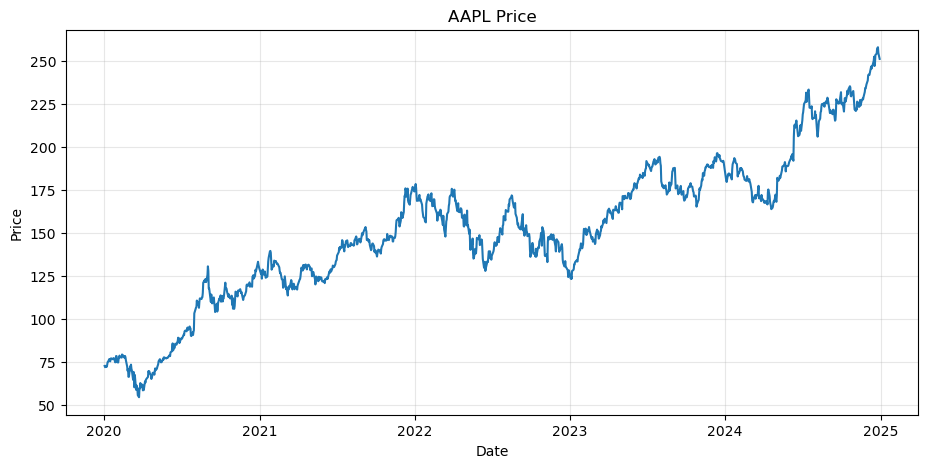

Log-returns (5 premières lignes) :
Ticker          AAPL
Date                
2020-01-03 -0.009770
2020-01-06  0.007937
2020-01-07 -0.004715
2020-01-08  0.015959
2020-01-09  0.021018 



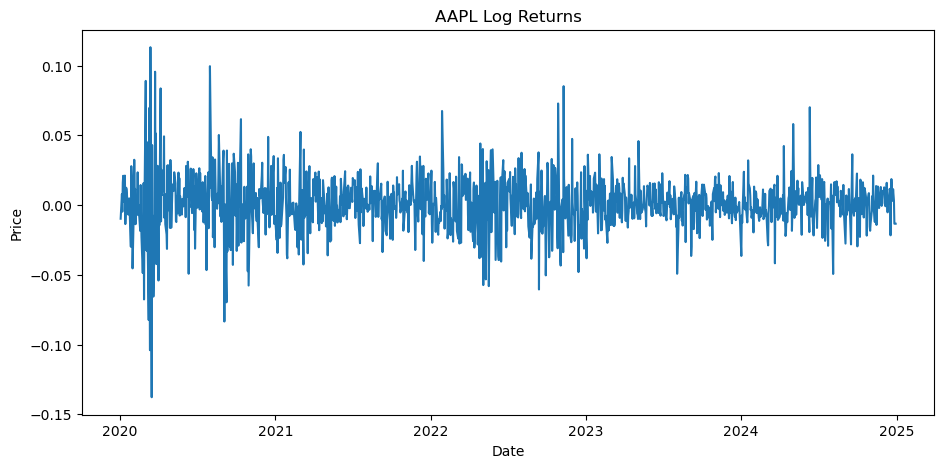

/var/folders/v1/6gl718t54z7gd7nfbscyfvgm0000gn/T/ipykernel_90219/21779547.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu = float(log_returns.mean())
/var/folders/v1/6gl718t54z7gd7nfbscyfvgm0000gn/T/ipykernel_90219/21779547.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma = float(log_returns.std())
/var/folders/v1/6gl718t54z7gd7nfbscyfvgm0000gn/T/ipykernel_90219/2956670198.py:33: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(stock_data['Close'].iloc[-1])    # début à partir du dernier prix du stock


Paramètres journaliers estimés : mu=0.000989, sigma=0.019947
Annualisés : mu=0.2493, sigma=0.3166



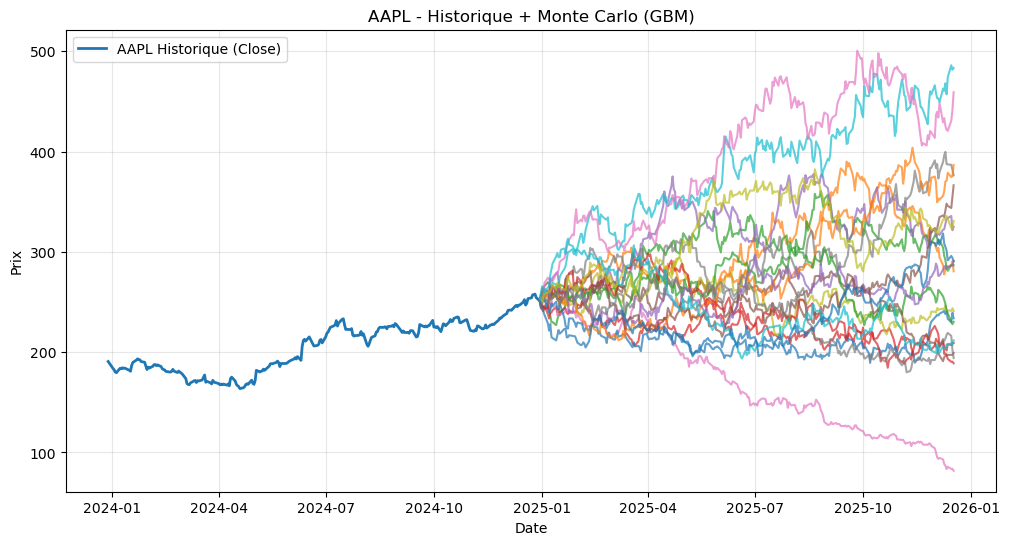

Analyse de mu et sigma :

- Approche aléatoire : choisir mu et sigma ‘au hasard’ n’a pas de sens économique/statistique :
  les trajectoires deviennent arbitraires et non calibrées au marché (fluctuations non réalistes).

- Approche historique : estimer mu et sigma à partir des log-returns historiques est une meilleure approche (fluctuations plus réalistes).

  Période courte vs longue :
  * Estimation longue  : mu=0.000989, sigma=0.019947
  * Estimation courte  : mu=0.001772, sigma=0.010607

  En général, sur une période courte, mu est très instable (bruit, régime de marché),
  et sigma peut être surestimé/sous-estimé si la période contient un choc (earnings, crise, etc.).
  Sur une longue période, mu/sigma sont plus ‘lissés’ mais peuvent mélanger plusieurs régimes (directionnel, consolidation, crises, etc.).



/var/folders/v1/6gl718t54z7gd7nfbscyfvgm0000gn/T/ipykernel_90219/21779547.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu = float(log_returns.mean())
/var/folders/v1/6gl718t54z7gd7nfbscyfvgm0000gn/T/ipykernel_90219/21779547.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma = float(log_returns.std())


In [30]:
def main():
    
    # Paramètres initiaux à modifier
    ticker = "AAPL"                             # exemples : "^GSPC" pour S&P500, "MSFT", "TSLA", etc.
    start_date = "2020-01-01"
    end_date = "2024-12-31"

    # Téléchargement + plot des données historiques
    stock_data = download_data(ticker, start_date, end_date)
    plot_price(stock_data, ticker)

    # Calcul + plot des log returns 
    stock_log_returns = compute_log_returns(stock_data)
    print("Log-returns (5 premières lignes) :")
    print(stock_log_returns.head(), "\n")
    plot_log_returns(stock_log_returns, ticker)

    # Calcul de mu et sigma journaliers
    mu, sigma = estimate_mu_sigma(stock_log_returns)
    print(f"Paramètres journaliers estimés : mu={mu:.6f}, sigma={sigma:.6f}")

    # Paramètres annualisés
    annual_mu = mu * 252
    annual_sigma = sigma * np.sqrt(252)
    print(f"Annualisés : mu={annual_mu:.4f}, sigma={annual_sigma:.4f}\n")

    # Paramètres à modifier
    n_steps = 252                               # 252 sur 1 an ou len(stock_log_returns) sur plusieurs années
    n_paths = 20
    n_seed = 10

    # Paramètres fixes
    S0 = float(stock_data['Close'].iloc[-1])    # début à partir du dernier prix du stock
    dt = 1                                      # variations/fréquences journalières en fonction de mu et sigma

    # Simulation des trajectoires de Monte Carlo selon GBM
    df_paths = simulate_mc_paths(S0, dt, mu, sigma, n_steps, n_paths, n_seed)

    # Plot historique + trajectoires MC
    plot_history_with_mc(stock_data, df_paths, ticker)

    # Comparaison long vs court (dernier trimestre environ)
    short_df = stock_data.iloc[-63:]  # ~ 3 mois de bourse
    short_log = compute_log_returns(short_df)
    mu_short, sigma_short = estimate_mu_sigma(short_log)

    print(mu_sigma_analyse(mu, sigma, mu_short, sigma_short))

main()
